In [47]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

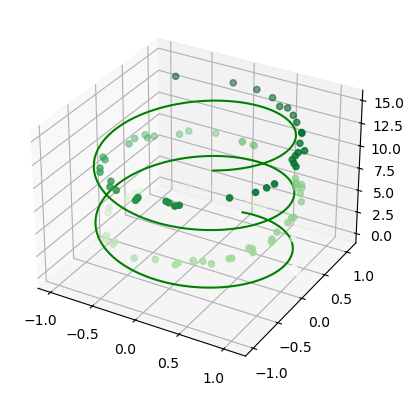

In [57]:
# Трёхмерные точки и линии

fig = plt.figure()
ax = plt.axes(projection='3d')

z1 = np.linspace(0, 15, 1000) #Линии
y1 = np.cos(z1)
x1 = np.sin(z1)

ax.plot3D(x1, y1, z1, 'green')

z2 = 15*np.random.random(100)  #Точки
x2 = np.cos(z2) + 0.1*np.random.random(100)
y2 = np.sin(z2) + 0.1*np.random.random(100)

ax.scatter3D(x2, y2, z2, c=z2, cmap='Greens')

plt.show()

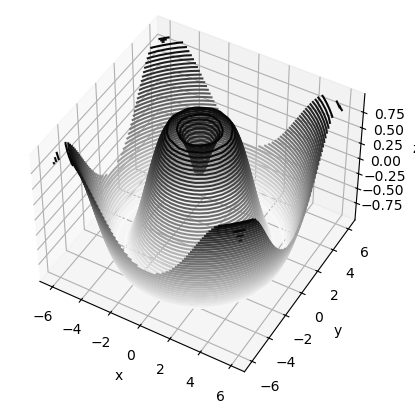

In [67]:
fig = plt.figure()
ax = plt.axes(projection='3d')

def f(x,y):
    return np.sin(np.sqrt(x**2 + y**2))


x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X,Y = np.meshgrid(x,y)
Z = f(X,Y)

ax.contour3D(X, Y, Z, 40, cmap='binary')

ax.set_xlabel('x') # Оси
ax.set_ylabel('y')
ax.set_zlabel('z')


ax.view_init(45) # угол просмотра

plt.show()

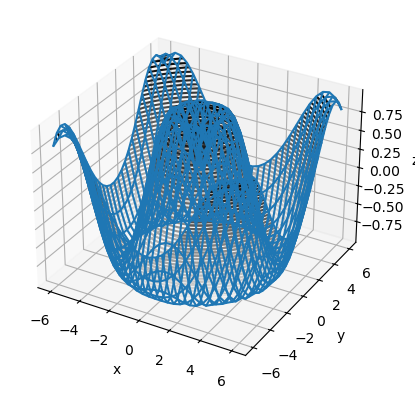

In [69]:
# Каркасный

fig = plt.figure()
ax = plt.axes(projection='3d')

def f(x,y):
    return np.sin(np.sqrt(x**2 + y**2))


x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X,Y = np.meshgrid(x,y)
Z = f(X,Y)

ax.contour3D(X, Y, Z, 40, cmap='binary')

ax.set_xlabel('x') # Оси
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.plot_wireframe(X, Y, Z)

plt.show()

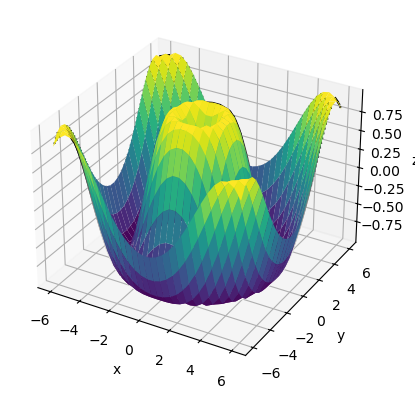

In [71]:
# Поверхностный

fig = plt.figure()
ax = plt.axes(projection='3d')

def f(x,y):
    return np.sin(np.sqrt(x**2 + y**2))


x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X,Y = np.meshgrid(x,y)
Z = f(X,Y)

ax.contour3D(X, Y, Z, 40, cmap='binary')

ax.set_xlabel('x') # Оси
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

plt.show()

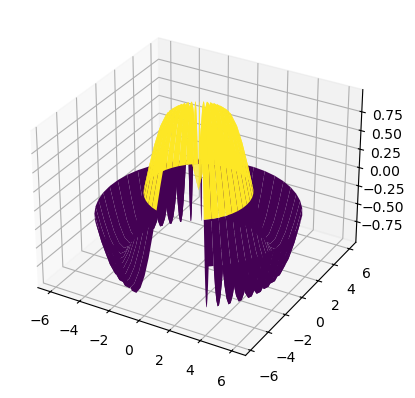

In [81]:
# Срез
fig = plt.figure()
ax = plt.axes(projection='3d')

r = np.linspace(0, 6, 20)
theta = np.linspace(-0.9 * np.pi, 0.8*np.pi, 40)

R, Theta = np.meshgrid(r, theta)

X = r * np.sin(Theta)
Y = r * np.cos(Theta)
Z = f(X, Y)

ax.plot_surface(X, Y, Z, rstride=1, cmap='viridis', edgecolor='none')

plt.show()

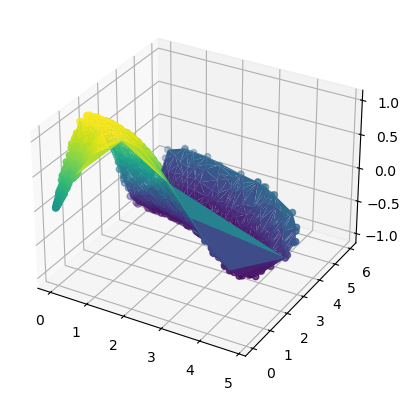

In [83]:
# Триангуляция
fig = plt.figure()
ax = plt.axes(projection='3d')

theta = 2 * np.pi + np.random.random(1000)
r = 6 * np.random.random(1000)

x = r * np.sin(theta)
y = r * np.cos(theta)
z = f(x,y)

ax.scatter(x, y, z, c=z, cmap='viridis')

ax.plot_trisurf(x,y,z,cmap='viridis')

plt.show()

          x         y
0  6.258849  2.177738
1  0.252997 -0.656129
2  1.043490 -0.506391
3 -1.523371  0.089218
4  1.422225  1.649091


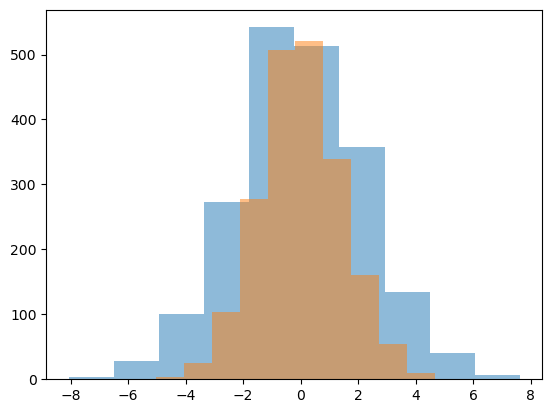

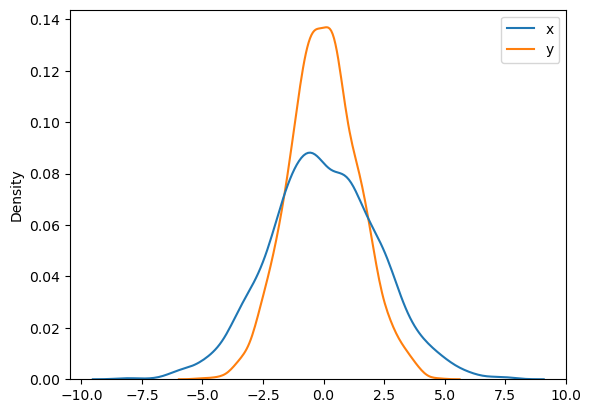

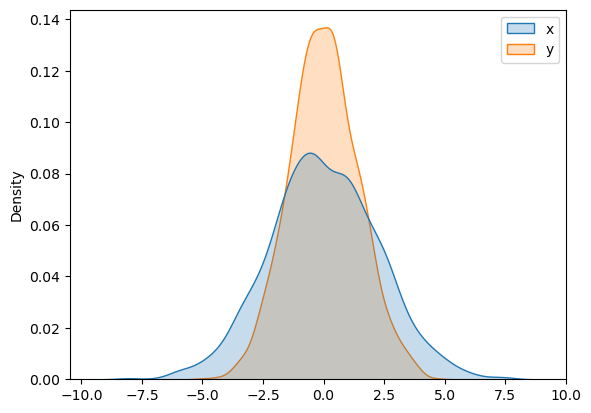

In [95]:
import seaborn as sns
# - DataFrame (Matplotlib с Pandas)
# - более высокоуровневый

data = np.random.multivariate_normal([0,0], [[5,2], [2,2]], size = 2000)
data = pd.DataFrame(data, columns=['x','y'])
print(data.head())

fig = plt.figure()
plt.hist(data['x'], alpha = 0.5)
plt.hist(data['y'], alpha = 0.5)

fig = plt.figure()
sns.kdeplot(data=data)

fig = plt.figure()
sns.kdeplot(data=data, fill=True) # shade

plt.show()

In [99]:
iris = sns.load_dataset('iris')
print(iris.head())

plt.show()

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


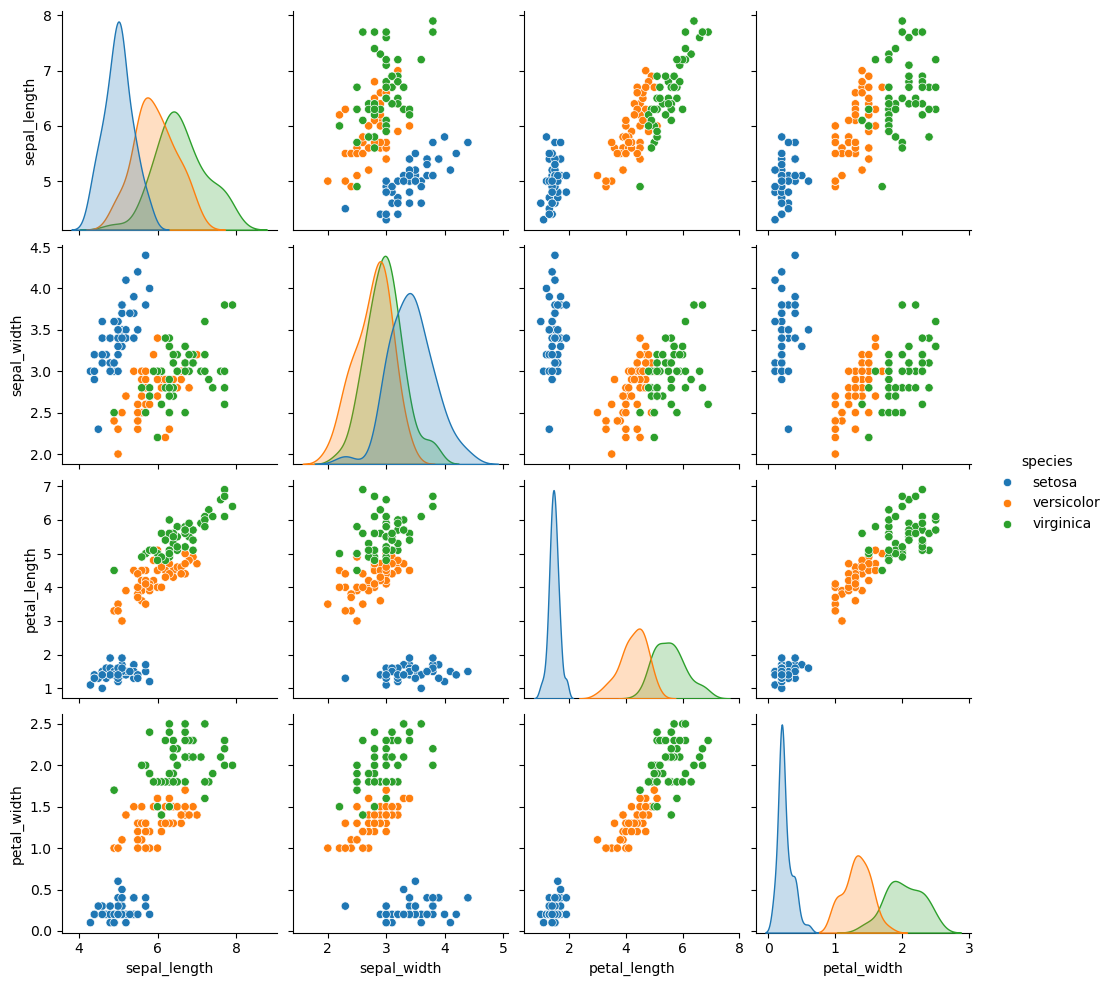

In [103]:
sns.pairplot(iris, hue='species')

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


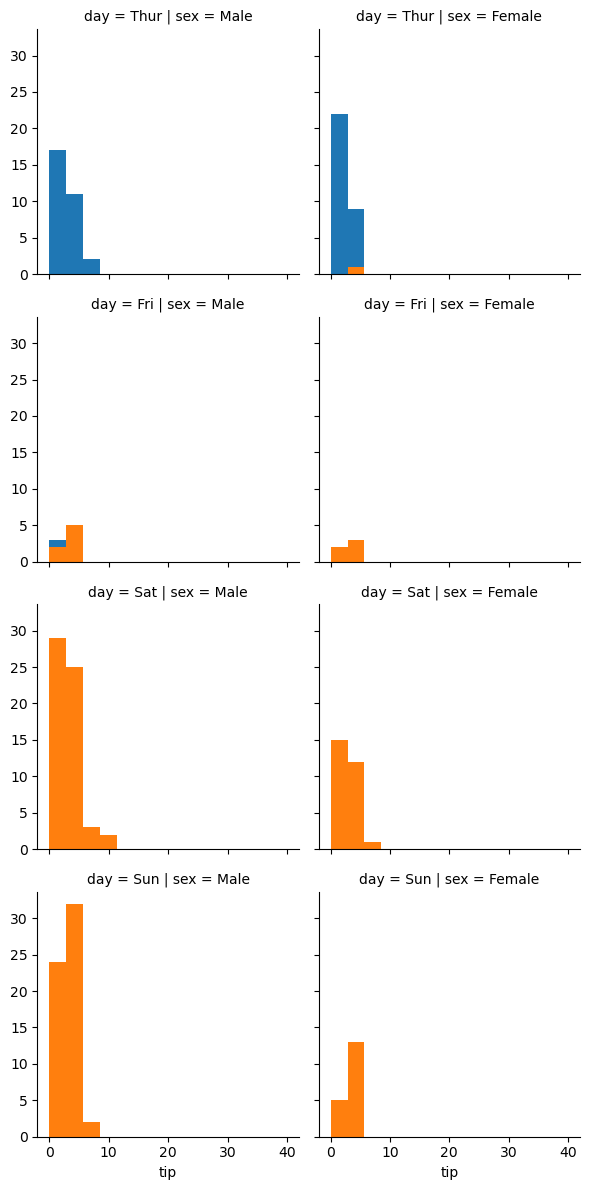

In [123]:
tips = sns.load_dataset('tips')
print(tips.head())

# Гистограммы
grid = sns.FacetGrid(tips, row = 'day', col='sex', hue='time')
grid.map(plt.hist, 'tip', bins=np.linspace(0,40,15))

plt.show()

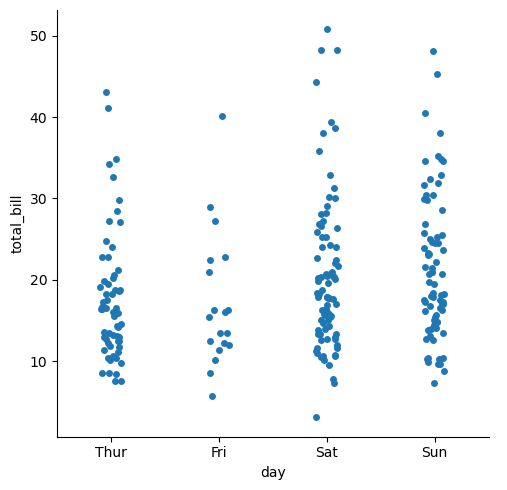

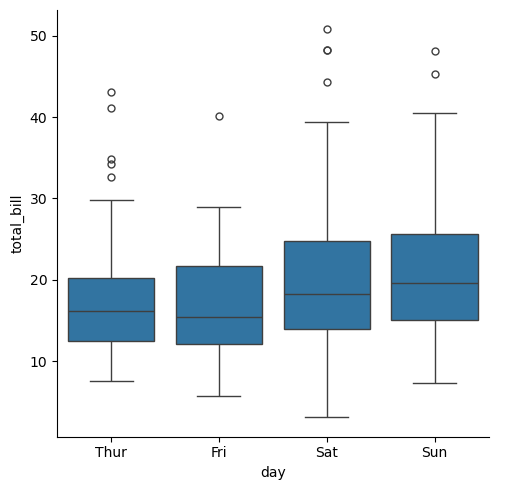

In [127]:
sns.catplot(data=tips,x='day', y='total_bill')

sns.catplot(data=tips,x='day', y='total_bill', kind='box')

plt.show()

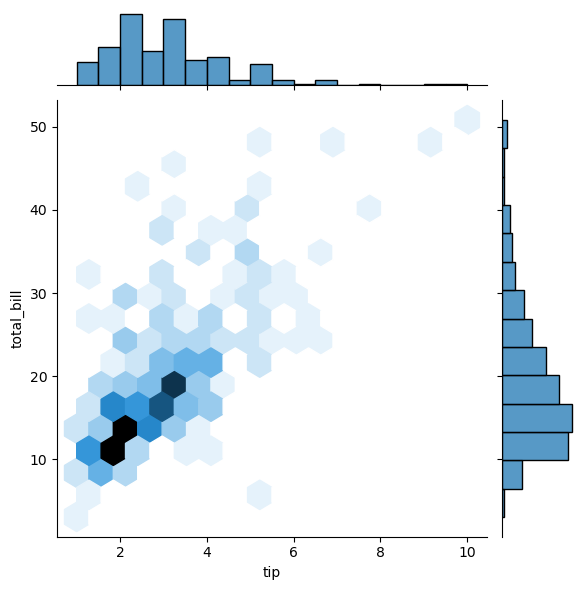

In [131]:
sns.jointplot(data=tips,x='tip', y='total_bill', kind='hex')

plt.show()

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


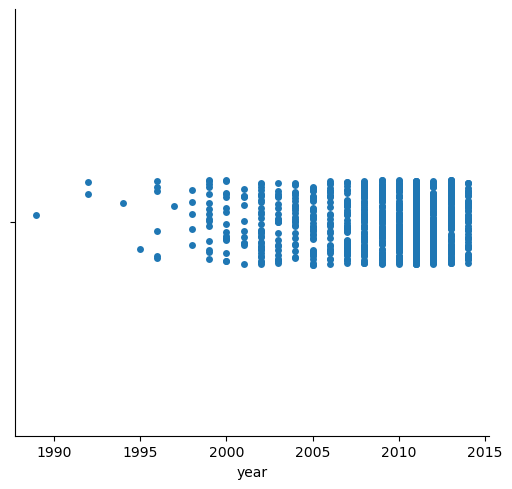

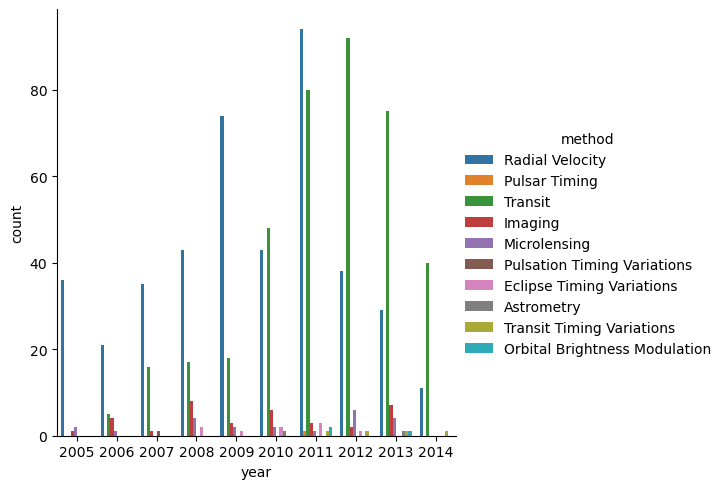

In [141]:
planets = sns.load_dataset('planets')
print(planets.head())

sns.catplot(data=planets, x='year', kind='strip')

sns.catplot(data=planets, x='year', kind='count', hue='method',order=range(2005, 2015))

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


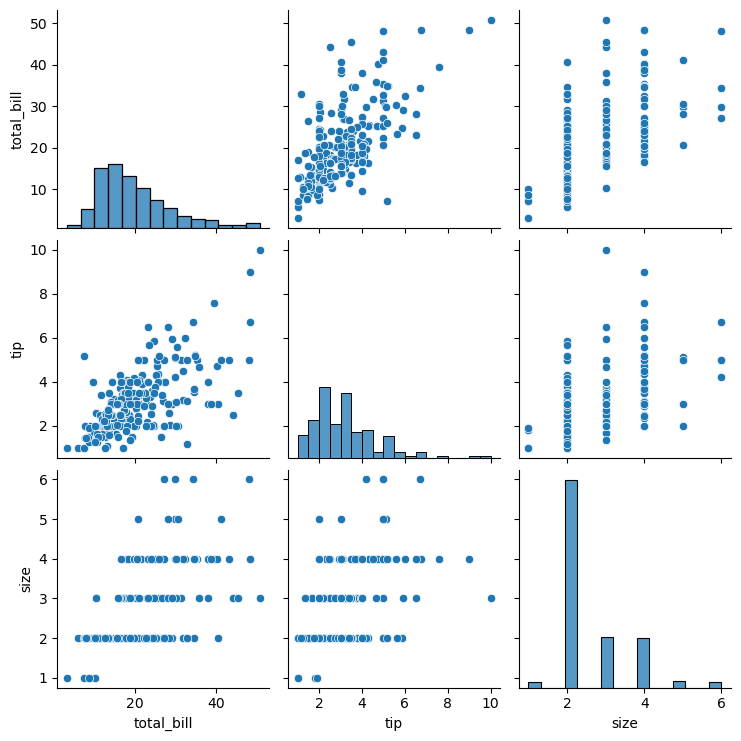

In [151]:
tips = sns.load_dataset('tips')
print(tips.head())

# Сравнение числовых данных

## Числовые пары
sns.pairplot(tips)

plt.show()

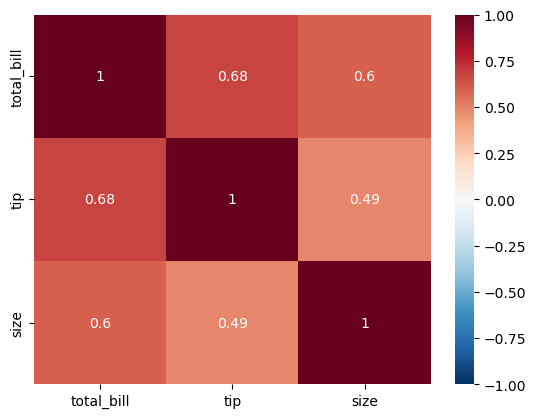

In [155]:
## Тепловая карта
tips_corr = tips[['total_bill', 'tip', 'size']]
sns.heatmap(tips_corr.corr(),cmap='RdBu_r', annot=True, vmin=-1, vmax=1)
# 0 - независимы
# 1 - положительная
# -1 - отрицательная
plt.show()

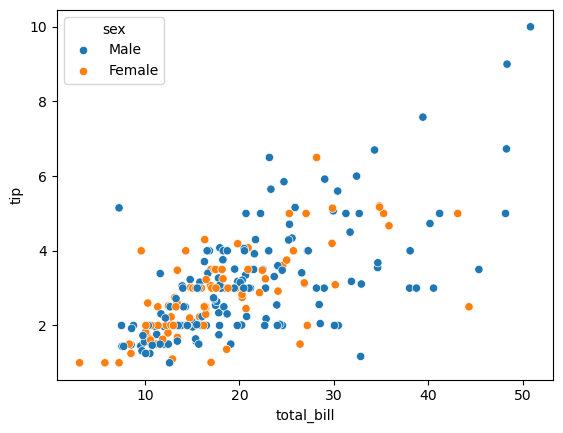

In [157]:
## Диаграмма рассеяния

sns.scatterplot(data=tips,  x='total_bill', y='tip', hue='sex')

plt.show()

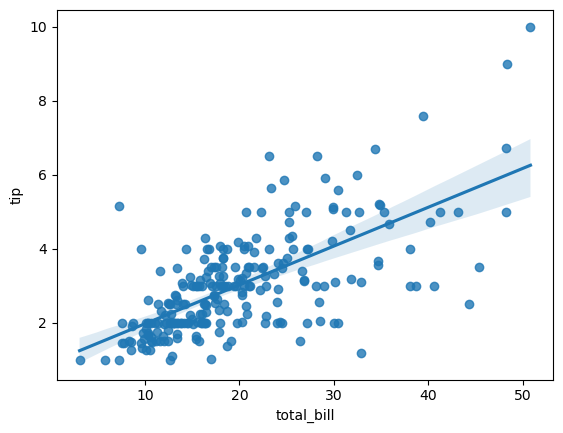

In [161]:
# с лин. регрессией
sns.regplot(data=tips,  x='total_bill', y='tip')

plt.show()

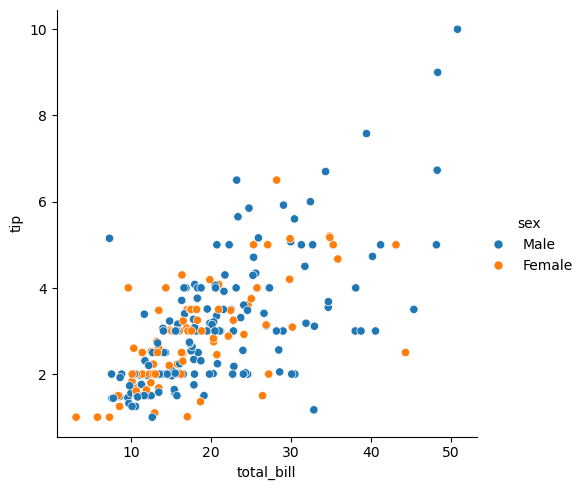

In [165]:
sns.relplot(data=tips,  x='total_bill', y='tip', hue='sex')

plt.show()

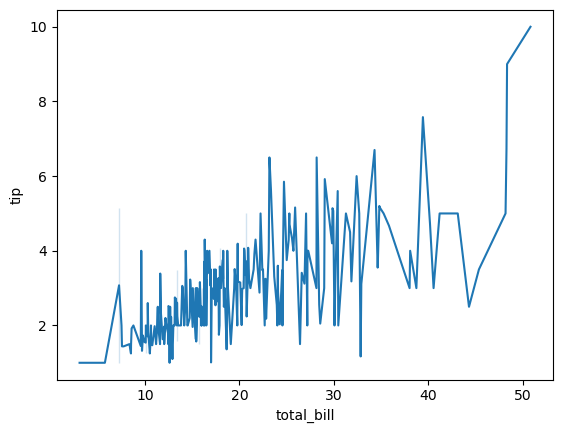

In [167]:
## Линейный график
sns.lineplot(data=tips,  x='total_bill', y='tip')

plt.show()

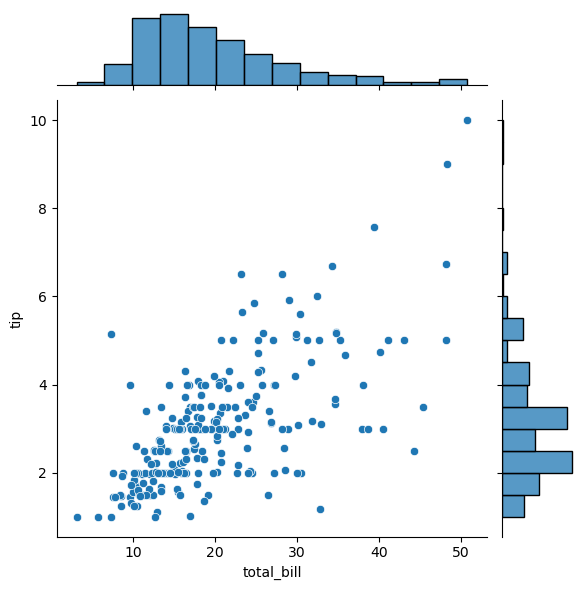

In [169]:
## Сводная диаграмма
sns.jointplot(data=tips,  x='total_bill', y='tip')

plt.show()

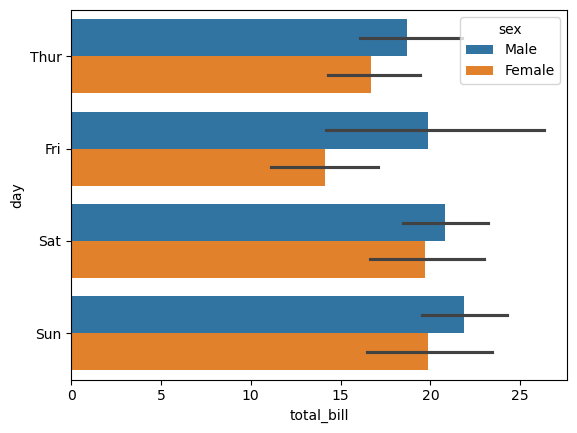

In [173]:
# сравнение числовых и категориальных данных
## Гистограммы
sns.barplot(data=tips,  x='total_bill', y='day', hue='sex')

plt.show()

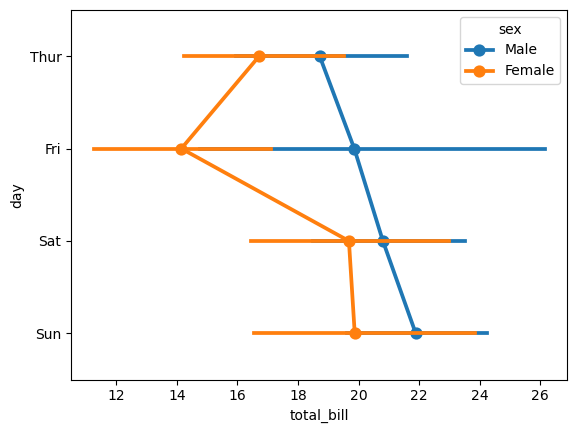

In [175]:
sns.pointplot(data=tips,  x='total_bill', y='day', hue='sex')

plt.show()

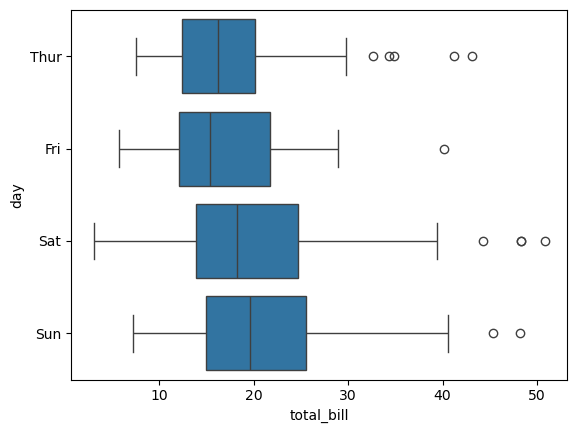

In [177]:
## Бокс плот
sns.boxplot(data=tips,  x='total_bill', y='day')

plt.show()

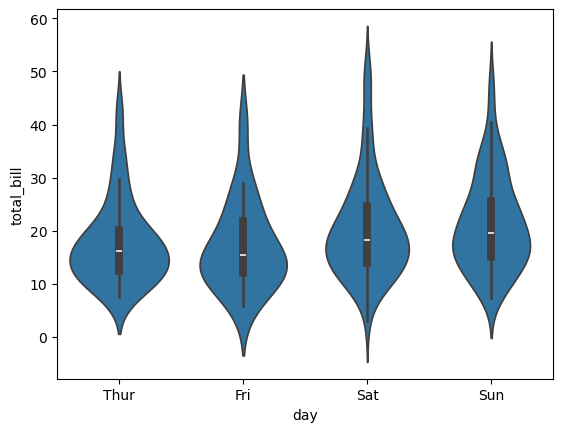

In [181]:
# Скрипичная диаграмма
sns.violinplot(data=tips,  y='total_bill', x='day')

plt.show()

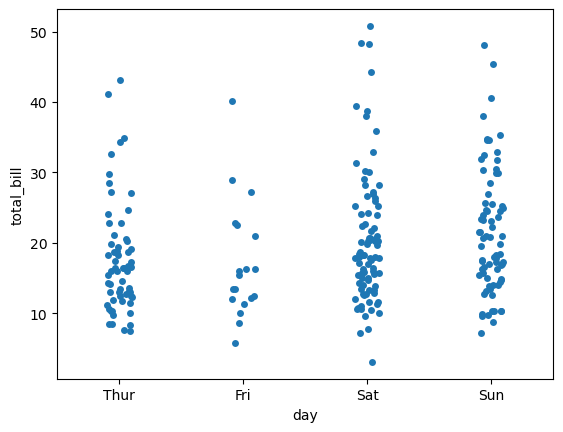

In [183]:
# Одномерная диграмма рассеяния
sns.stripplot(data=tips,  y='total_bill', x='day')

plt.show()